# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [7]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /home/cliffpm/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [ ]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


## 3. Load the Data

In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    path = '/mnt/c/Users/cliff/Downloads/tinyml_env_setup_package/tinyml_env_setup_package'

    X_train = pd.read_csv(path + "/UCI HAR Dataset/train/X_train.txt", sep = '\s+', header = None).values
    X_test = pd.read_csv(path + "/UCI HAR Dataset/test/X_test.txt", sep = '\s+', header = None).values
    y_train = pd.read_csv(path + "/UCI HAR Dataset/train/y_train.txt", sep = '\s+', header = None).values.flatten()
    y_test = pd.read_csv(path + "/UCI HAR Dataset/test/y_test.txt", sep = '\s+', header = None).values.flatten()

    y_test -= 1
    y_train-= 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.
num_classes = len(class_names)

num_features = X_train.shape[1]
# <-- Enter your code here <--#


## 4. Quick Inspection

In [5]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

unique, counts = np.unique(y_train, return_counts=True)
counts_dict = dict(zip(unique, counts))

# 2. Create the summary data
summary_data = []
for i, name in enumerate(class_names):
    summary_data.append({
        "Class Index": i,
        "Class Name": name,
        "Training Samples": counts_dict.get(i, 0)
    })

# 3. Create and display the DataFrame
df_summary = pd.DataFrame(summary_data)

print("Dataset Summary:")
print(df_summary.to_string(index=False))


Dataset Summary:
 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [8]:
def build_baseline_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape = (input_dim,)),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(64, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax')
    ])

    lr_val = .001

    optim = tf.keras.optimizers.Adam(learning_rate = lr_val)
    
    
    model.compile(
        optimizer = optim,
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
        


    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

hist = baseline_model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 7ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

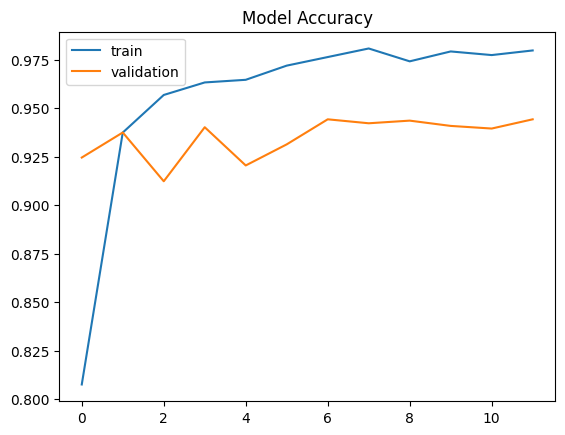

In [10]:
plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.legend()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 2ms/step - loss: 0.2288 - accuracy: 0.9243
test accuracy : 0.9243298172950745
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       496
           1       0.88      0.93      0.91       471
           2       0.99      0.82      0.90       420
           3       0.93      0.89      0.91       491
           4       0.87      0.94      0.90       532
           5       1.00      0.96      0.98       537

    accuracy                           0.92      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.92      0.92      2947



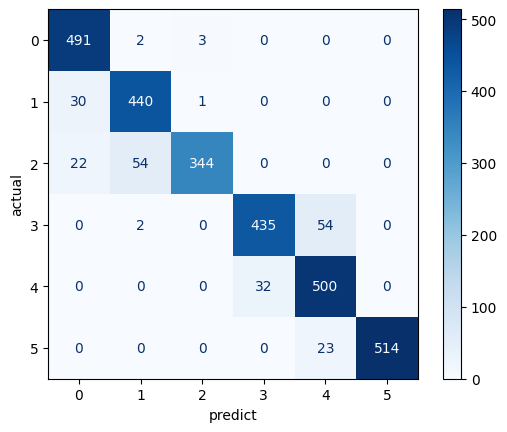

In [11]:
predicted = baseline_model.predict(X_test)

predictions = np.argmax(predicted, axis = 1)


res = baseline_model.evaluate(X_test, y_test)
print(f"test accuracy : {res[1]}")

print(classification_report(y_test,predictions))

# cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap = plt.cm.Blues)
plt.xlabel('predict')
plt.ylabel('actual')
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [27]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]
    y_pred = []

    for i in range(len(X)):
        input_data = X[i:i+1].astype(np.float32)

        if input_dtype == np.int8:
            input_data = np.round(input_data / input_scale + input_zero_point).astype(np.int8)
        elif input_dtype == np.uint8:
            input_data = np.round(input_data / input_scale + input_zero_point).astype(np.uint8)
        else:
            input_data = input_data.astype(input_dtype)

        interpreter.set_tensor(input_details["index"], input_data)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_dtype in (np.int8, np.uint8) and output_scale != 0:
            output = (output.astype(np.float32) - output_zero_point) * output_scale


        # <-- Enter your code here <--#

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    tflitemodel = converter.convert()
    return tflitemodel


def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.float16]
    tflitemodel = converter.convert()
    return tflitemodel


## 8. Convert the Baseline Model to TensorFlow Lite

In [15]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)



INFO:tensorflow:Assets written to: /tmp/tmpl2o3v7fj/assets


INFO:tensorflow:Assets written to: /tmp/tmpl2o3v7fj/assets
2026-04-19 20:58:17.685048: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 20:58:17.685100: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 20:58:17.685259: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpl2o3v7fj
2026-04-19 20:58:17.686296: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 20:58:17.686315: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpl2o3v7fj
2026-04-19 20:58:17.689984: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 20:58:17.732354: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpl2o3v7fj
2026-04-19 20:58:17.745478: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [19]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.

steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

pruning_params = {
    "pruning_schedule" : PolynomialDecay(
        initial_sparsity = 0.50,
        final_sparsity = 0.90,
        begin_step = 0,
        end_step = steps_per_epoch * pruning_epochs
    )
}


# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(baseline_model, **pruning_params)
lr_val = .001

optim = tf.keras.optimizers.Adam(learning_rate = lr_val)

pruned_model.compile(


    optimizer = optim,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)



pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

history_pruned = pruned_model.fit(
    X_train,
    y_train,
    validation_data = (X_test, y_test),
    epochs = pruning_epochs,
    batch_size = batch_size,
    callbacks = pruning_callbacks,
)
# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#


Epoch 1/12
115/115 [==============================] - 3s 8ms/step - loss: 0.1051 - accuracy: 0.9608 - val_loss: 0.1678 - val_accuracy: 0.9410
Epoch 2/12
115/115 [==============================] - 1s 6ms/step - loss: 0.0592 - accuracy: 0.9796 - val_loss: 0.1391 - val_accuracy: 0.9505
Epoch 3/12
115/115 [==============================] - -2s -19211us/step - loss: 0.0683 - accuracy: 0.9740 - val_loss: 0.1395 - val_accuracy: 0.9501
Epoch 4/12
115/115 [==============================] - 1s 6ms/step - loss: 0.0907 - accuracy: 0.9678 - val_loss: 0.1337 - val_accuracy: 0.9505
Epoch 5/12
115/115 [==============================] - 1s 6ms/step - loss: 0.1260 - accuracy: 0.9633 - val_loss: 0.1436 - val_accuracy: 0.9464


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [22]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.
tflite_pruned_wrapped = convert_to_tflite_fp32(pruned_model)
size_wrapped = save_binary_model(tflite_pruned_wrapped, "model_prunned_wrapped.tflite")
acc_wrapped, _ = evaluate_tflite_model(tflite_pruned_wrapped, X_test, y_test)

stripped_model = strip_pruning(pruned_model)
converter_sparse = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_sparse.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]

tflite_pruned_sparse = converter_sparse.convert()
size_sparse = save_binary_model(tflite_pruned_sparse, "model_pruned_sparse.tflite")
acc_sparse, _ = evaluate_tflite_model(tflite_pruned_sparse, X_test, y_test)


INFO:tensorflow:Assets written to: /tmp/tmpydq7p9ai/assets


INFO:tensorflow:Assets written to: /tmp/tmpydq7p9ai/assets
2026-04-19 21:34:06.744035: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 21:34:06.744132: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 21:34:06.744436: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpydq7p9ai
2026-04-19 21:34:06.749794: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 21:34:06.749842: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpydq7p9ai
2026-04-19 21:34:06.764486: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 21:34:06.846647: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpydq7p9ai
2026-04-19 21:34:06.876864: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpe51xeo8t/assets


INFO:tensorflow:Assets written to: /tmp/tmpe51xeo8t/assets
2026-04-19 21:34:08.360675: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 21:34:08.360753: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 21:34:08.360932: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpe51xeo8t
2026-04-19 21:34:08.361746: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 21:34:08.361761: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpe51xeo8t
2026-04-19 21:34:08.363857: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 21:34:08.387483: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpe51xeo8t
2026-04-19 21:34:08.396576: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 11. Part I Comparison: Accuracy and Model Size

In [23]:
comparison_data = {
    "Model": [
        "Baseline", 
        "Pruned (Wrapped)", 
        "Pruned (Stripped+Sparse)"
    ],
    "Format": [
        "FP32 TFLite", 
        "FP32 TFLite with mask", 
        "FP32 TFLite Sparse"
    ],
    "Test Accuracy": [
        acc_fp32, 
        acc_wrapped, 
        acc_sparse
    ],
    "Model Size (KB)": [
        size_fp32, 
        size_wrapped, 
        size_sparse
    ]
}

df_part_1 = pd.DataFrame(comparison_data)

print("Part I: Pruning and Sparsity Comparison")
display(df_part_1)

Part I: Pruning and Sparsity Comparison


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.924330,726.718750
1,Pruned (Wrapped),FP32 TFLite with mask,0.950458,1454.101562
2,Pruned (Stripped+Sparse),FP32 TFLite Sparse,0.950458,182.640625


/tmp/ipykernel_2292/142174758.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_size_sorted, x="Model", y="Model Size (KB)", palette="viridis")
/tmp/ipykernel_2292/142174758.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_acc_sorted, x="Model", y="Test Accuracy", palette="magma")


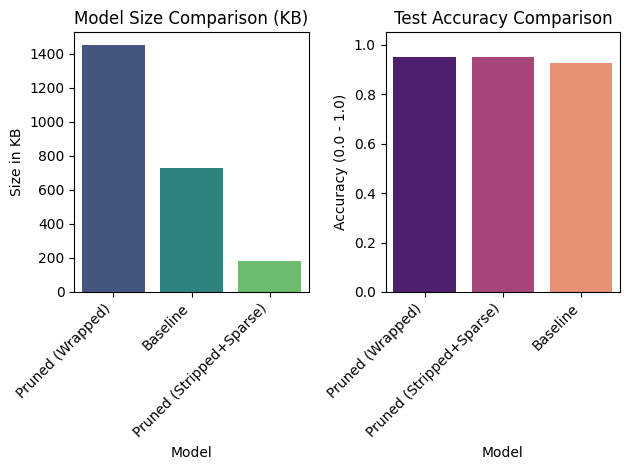

In [24]:
import seaborn as sns

df_size_sorted = df_part_1.sort_values("Model Size (KB)", ascending=False)
df_acc_sorted = df_part_1.sort_values("Test Accuracy", ascending=False)


plt.subplot(1, 2, 1)
sns.barplot(data=df_size_sorted, x="Model", y="Model Size (KB)", palette="viridis")
plt.title("Model Size Comparison (KB)")
plt.xticks(rotation=45, ha='right') 
plt.ylabel("Size in KB")

plt.subplot(1, 2, 2)
sns.barplot(data=df_acc_sorted, x="Model", y="Test Accuracy", palette="magma")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (0.0 - 1.0)")
plt.ylim(0, 1.05) 

plt.tight_layout()
plt.savefig("pruning_results_comparison.png")

### Confusion Matrix for the Stripped Sparse Model

In [ ]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


Classification Report: Stripped Sparse TFLite Model
                    precision    recall  f1-score   support

           WALKING       0.93      0.98      0.96       496
  WALKING_UPSTAIRS       0.97      0.92      0.95       471
WALKING_DOWNSTAIRS       0.97      0.97      0.97       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



<Figure size 1000x800 with 0 Axes>

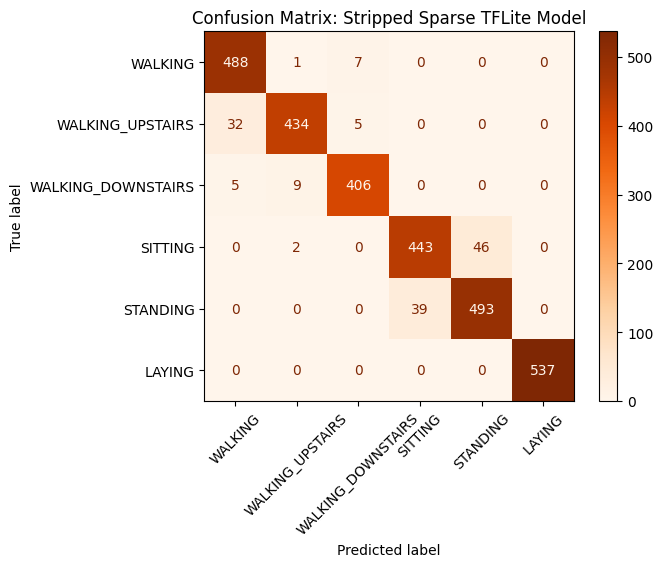

In [25]:
_, y_pred_sparse = evaluate_tflite_model(tflite_pruned_sparse, X_test, y_test)

print("Classification Report: Stripped Sparse TFLite Model")
print(classification_report(y_test, y_pred_sparse, target_names=class_names))

plt.figure(figsize=(10, 8))
cm_sparse = confusion_matrix(y_test, y_pred_sparse)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sparse, display_labels=class_names)

disp.plot(cmap=plt.cm.Oranges, xticks_rotation=45)
plt.title("Confusion Matrix: Stripped Sparse TFLite Model")
plt.show()

## 12. Part II Comparison: Accuracy and Model Size

In [29]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

tflite_pruned_f16_wrapped = convert_to_tflite_float16(pruned_model)
size_pruned_f16_wrapped = save_binary_model(tflite_pruned_f16_wrapped, "model_pruned_f16_wrapped.tflite")
acc_pruned_f16_wrapped, _ = evaluate_tflite_model(tflite_pruned_f16_wrapped, X_test, y_test)


converter_f16_sparse = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_f16_sparse.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter_f16_sparse.target_spec.supported_types = [tf.float16] 

tflite_pruned_f16_sparse = converter_f16_sparse.convert()
size_pruned_f16_sparse = save_binary_model(tflite_pruned_f16_sparse, "model_pruned_f16_sparse.tflite")
acc_pruned_f16_sparse, _ = evaluate_tflite_model(tflite_pruned_f16_sparse, X_test, y_test)

comparison_data_v2 = {
    "Model": [
        "Pruned (Wrapped)", 
        "Pruned (Stripped+Sparse)", 
        "Pruned (Wrapped)", 
        "Pruned (Stripped+Sparse)"
    ],
    "Format": [
        "FP32", 
        "FP32 Sparse", 
        "Float16", 
        "Float16 Sparse"
    ],
    "Test Accuracy": [
        acc_wrapped, 
        acc_sparse, 
        acc_pruned_f16_wrapped, 
        acc_pruned_f16_sparse
    ],
    "Model Size (KB)": [
        size_wrapped, 
        size_sparse, 
        size_pruned_f16_wrapped, 
        size_pruned_f16_sparse
    ]
}

df_part_2 = pd.DataFrame(comparison_data_v2)
print(df_part_2)


INFO:tensorflow:Assets written to: /tmp/tmpa8v9afnj/assets


INFO:tensorflow:Assets written to: /tmp/tmpa8v9afnj/assets
2026-04-19 21:42:40.707588: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 21:42:40.707671: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 21:42:40.707877: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpa8v9afnj
2026-04-19 21:42:40.713842: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 21:42:40.713876: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpa8v9afnj
2026-04-19 21:42:40.728930: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 21:42:40.799748: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpa8v9afnj
2026-04-19 21:42:40.825766: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpk394tnqj/assets


INFO:tensorflow:Assets written to: /tmp/tmpk394tnqj/assets


                      Model          Format  Test Accuracy  Model Size (KB)
0          Pruned (Wrapped)            FP32       0.950458      1454.101562
1  Pruned (Stripped+Sparse)     FP32 Sparse       0.950458       182.640625
2          Pruned (Wrapped)         Float16       0.950458      1454.105469
3  Pruned (Stripped+Sparse)  Float16 Sparse       0.950458       245.121094


2026-04-19 21:42:42.070532: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 21:42:42.070589: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 21:42:42.070770: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpk394tnqj
2026-04-19 21:42:42.071430: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 21:42:42.071443: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpk394tnqj
2026-04-19 21:42:42.073203: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 21:42:42.090704: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpk394tnqj
2026-04-19 21:42:42.098475: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 27703 m

/tmp/ipykernel_2292/3488954703.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_size_sorted, x="Format", y="Model Size (KB)", ax=ax1, palette="viridis")
/tmp/ipykernel_2292/3488954703.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_acc_sorted, x="Format", y="Test Accuracy", ax=ax2, palette="magma")


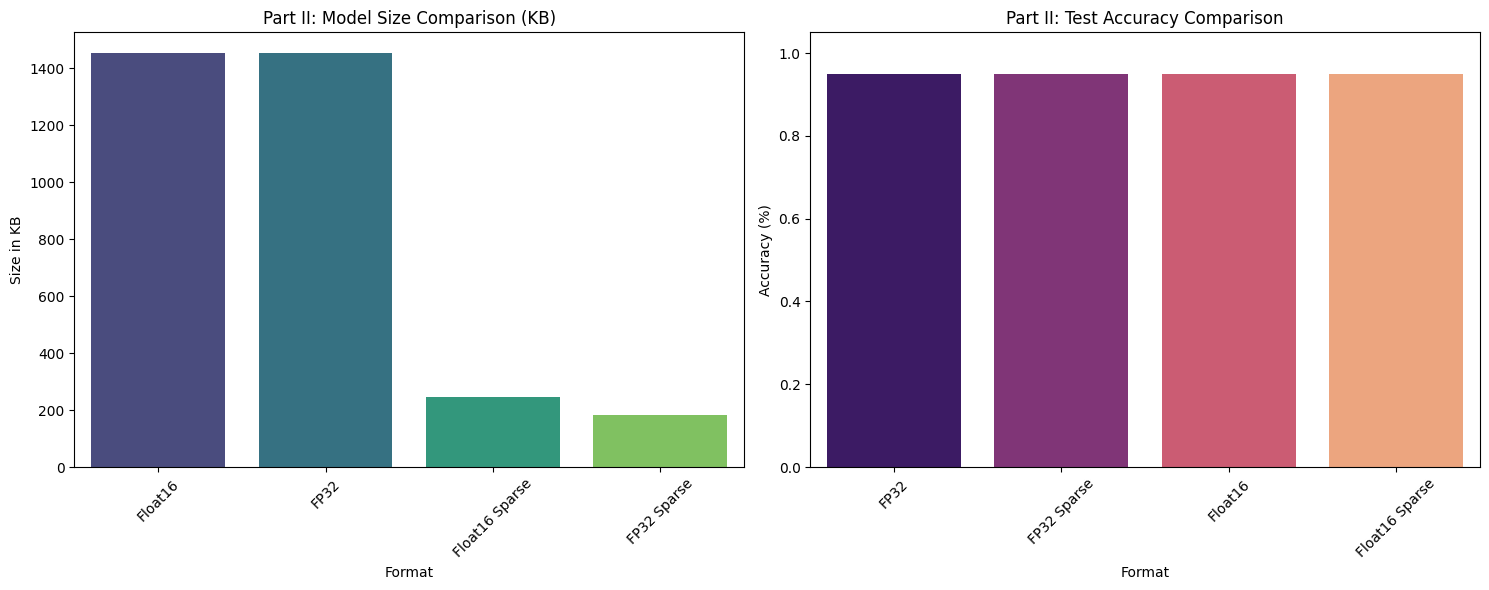

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


df_size_sorted = df_part_2.sort_values("Model Size (KB)", ascending=False)
sns.barplot(data=df_size_sorted, x="Format", y="Model Size (KB)", ax=ax1, palette="viridis")
ax1.set_title("Part II: Model Size Comparison (KB)")
ax1.set_ylabel("Size in KB")
ax1.tick_params(axis='x', rotation=45)


df_acc_sorted = df_part_2.sort_values("Test Accuracy", ascending=False)
sns.barplot(data=df_acc_sorted, x="Format", y="Test Accuracy", ax=ax2, palette="magma")
ax2.set_title("Part II: Test Accuracy Comparison")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 1.05) 
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("part_ii_metrics.png")
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification Report: Stripped Sparse + Float16 TFLite Model
                    precision    recall  f1-score   support

           WALKING       0.93      0.99      0.96       496
  WALKING_UPSTAIRS       0.97      0.92      0.95       471
WALKING_DOWNSTAIRS       0.97      0.96      0.97       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



<Figure size 1000x800 with 0 Axes>

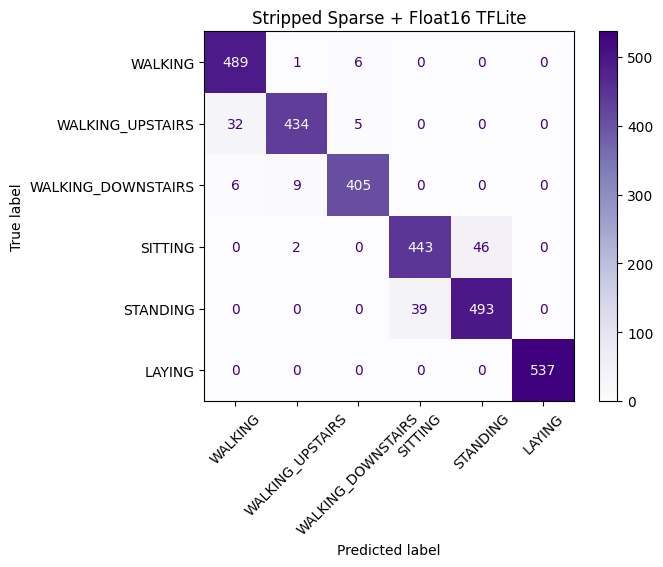

In [31]:
_, y_pred_f16_sparse = evaluate_tflite_model(tflite_pruned_f16_sparse, X_test, y_test)

print("Classification Report: Stripped Sparse + Float16 TFLite Model")
print(classification_report(y_test, y_pred_f16_sparse, target_names=class_names))

plt.figure(figsize=(10, 8))
cm_f16_sparse = confusion_matrix(y_test, y_pred_f16_sparse)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_f16_sparse, display_labels=class_names)

disp.plot(cmap=plt.cm.Purples, xticks_rotation=45)
plt.title("Stripped Sparse + Float16 TFLite")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached? No, because the pruning wrappers themselves still contributed to the overall size of the saved model.
2. Why does `strip_pruning(...)` matter before export? Because if we don't strip the pruning or removing the mask, our model will actually be 2x larger than the baseline model which defeats the purpose of the optimization techniques we learned in lecture.
3. Which model had the smallest file size in this notebook? In this case FP32 sparse model was smaller than the second smallest the FP16 sparse model, and this is due to using the experimental_sparsity parameter, it isn''t optimized for FP16 and can store more metadata for FP16.
4. Did float16 quantization noticeably change the test accuracy? No, the accuracy are roughly around the same for the other quantized models.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose the version that is the most smallest in size, since accuracy across all quantized and different variation of models remain realtively the same. In our result it would be the FP32 model, but theoretically the FP16 should be smaller in size.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
